#### Multilayer perceptron : fitting de una recta


MSE final = 0.042344554250653116
W1 =
 [[ 0.26217761]
 [-0.24445918]
 [-0.1820262 ]
 [ 0.18089744]
 [-0.42773446]]
b1 =
 [[-0.3509157 ]
 [ 0.18642938]
 [-1.02715839]
 [ 0.70891821]
 [ 1.36562101]]
W2 =
 [[ 2.11352371 -2.37678052 -1.72617369  2.24942905 -2.61362446]]
b2 =
 [[1.87467265]]

Predicciones finales:
x = 0.00   t = 1.20   y_pred = 1.1361
x = 0.50   t = 2.00   y_pred = 2.0120
x = 1.00   t = 3.10   y_pred = 2.9502
x = 1.50   t = 3.80   y_pred = 3.9509
x = 2.00   t = 5.20   y_pred = 5.0082
x = 2.50   t = 5.90   y_pred = 6.1040
x = 3.00   t = 7.10   y_pred = 7.2035
x = 3.50   t = 8.20   y_pred = 8.2580
x = 4.00   t = 8.80   y_pred = 9.2170
x = 4.50   t = 10.10   y_pred = 10.0433
x = 5.00   t = 11.00   y_pred = 10.7218


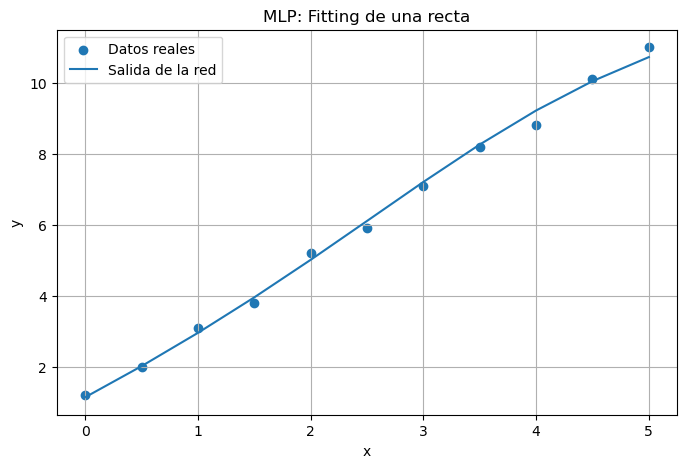

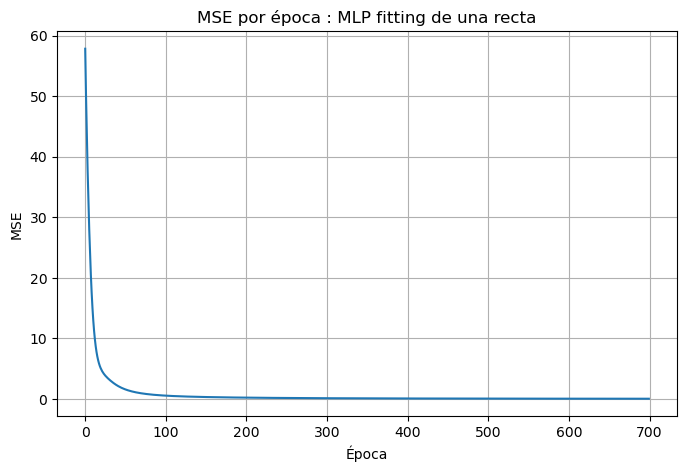

In [9]:
import numpy as np
import matplotlib.pyplot as plt

#datos de entrada
# p:entradas
# t:salidas (targets)

p = np.array([
    [0.0],
    [0.5],
    [1.0],
    [1.5],
    [2.0],
    [2.5],
    [3.0],
    [3.5],
    [4.0],
    [4.5],
    [5.0]
], dtype=float)

t = np.array([
    [1.2],
    [2.0],
    [3.1],
    [3.8],
    [5.2],
    [5.9],
    [7.1],
    [8.2],
    [8.8],
    [10.1],
    [11.0]
], dtype=float)

# Número de patrones
Q = len(p)

#funciones de activación y sus derivadas

# Activación no lineal para la capa oculta
def tansig(n):
    return np.tanh(n)

# Derivada de tanh
def dtansig(a):
    return 1.0 - a**2

# Activación lineal para la salida
def purelin(n):
    return n

# Derivada de la lineal
def dpurelin(a):
    return np.ones_like(a)


n_input = 1
n_hidden = 5
n_output = 1

# Semilla
np.random.seed(7)

# Inicialización aleatoria de pesos y bias
W1 = np.random.randn(n_hidden, n_input) * 0.5
b1 = np.random.randn(n_hidden, 1) * 0.5

W2 = np.random.randn(n_output, n_hidden) * 0.5
b2 = np.random.randn(n_output, 1) * 0.5

alpha = 0.001
epochs = 700 

#guardar el error por época
mse_list = []

#entrenamiento
for epoch in range(epochs):
    sum_error = 0.0

     
    for q in range(Q):

        # Entrada y target del patrón q
        a0 = p[q].reshape(-1, 1)   # entrada columna
        tq = t[q].reshape(-1, 1)   # target columna

        #forward 
        # a^1 = f^1(W^1 a^0 + b^1)
        # a^2 = f^2(W^2 a^1 + b^2)
        n1 = W1 @ a0 + b1
        a1 = tansig(n1)

        n2 = W2 @ a1 + b2
        a2 = purelin(n2)

        # ERROR
        # e_q = t_q - a_q^M
        e = tq - a2

        # Error cuadrático para acumular
        sum_error += np.sum(e**2)

        #backpropagation
        # s^M = -2 * F^M(n^M) * e_q
        # la salida es lineal, F^M = 1
        s2 = -2 * dpurelin(a2) * e

        # s^(m-1) = F^(m-1)(n^(m-1)) * (W^m)^T * s^m
        s1 = dtansig(a1) * (W2.T @ s2)

        #ACTUALIZACIÓN DE PESOS
        # W^m = W^m - alpha * s^m * (a^(m-1))^T
        # b^m = b^m - alpha * s^m
        W2 = W2 - alpha * (s2 @ a1.T)
        b2 = b2 - alpha * s2

        W1 = W1 - alpha * (s1 @ a0.T)
        b1 = b1 - alpha * s1

    #MSE de la época
    mse = sum_error / Q
    mse_list.append(mse)

#predicciones finales
y_pred = []

for q in range(Q):
    a0 = p[q].reshape(-1, 1)

    n1 = W1 @ a0 + b1
    a1 = tansig(n1)

    n2 = W2 @ a1 + b2
    a2 = purelin(n2)

    y_pred.append(a2.item())

y_pred = np.array(y_pred)

#resultados finales

print("\nMSE final =", mse_list[-1])

print("W1 =\n", W1)
print("b1 =\n", b1)
print("W2 =\n", W2)
print("b2 =\n", b2)

print("\nPredicciones finales:")
for entrada, real, pred in zip(p.flatten(), t.flatten(), y_pred):
    print(f"x = {entrada:.2f}   t = {real:.2f}   y_pred = {pred:.4f}")

#grafica de resultados
plt.figure(figsize=(8,5))
plt.scatter(p, t, label="Datos reales")
plt.plot(p, y_pred, label="Salida de la red")
plt.xlabel("x")
plt.ylabel("y")
plt.title("MLP: Fitting de una recta")
plt.grid(True)
plt.legend()
plt.show()

#grafica del mse por época
plt.figure(figsize=(8,5))
plt.plot(mse_list)
plt.xlabel("Época")
plt.ylabel("MSE")
plt.title("MSE por época : MLP fitting de una recta")
plt.grid(True)
plt.show()

#### Multilayer perceptron : 3 clases


MSE final = 0.004678179226539774
W1 =
 [[ 1.15905178  0.11486999]
 [-0.87661011  1.16390081]
 [-0.45647476 -0.51264494]
 [-0.12749699 -0.92614544]
 [ 0.7393105   0.54197964]
 [-0.86246808 -0.30938585]]
b1 =
 [[ 0.49619035]
 [ 0.09986174]
 [ 2.41168594]
 [-0.75330545]
 [ 0.44270786]
 [ 2.82065292]]
W2 =
 [[ 0.25222064  0.24085199  2.16467833 -0.13400672 -0.05001281  3.02777418]
 [-1.03450301 -3.34090363 -0.60644642 -0.05691731 -0.5132749  -1.69680202]
 [-0.85256803  2.93182935 -2.29484767  0.78002021 -1.5295692  -1.43964108]]
b2 =
 [[-0.35906736]
 [-0.3939368 ]
 [ 0.31480147]]

Accuracy = 1.0

Confusion Matrix:
[[20  0  0]
 [ 0 20  0]
 [ 0  0 20]]

Precision por clase:
Clase 0: 1.0000
Clase 1: 1.0000
Clase 2: 1.0000

Recall por clase:
Clase 0: 1.0000
Clase 1: 1.0000
Clase 2: 1.0000

Clase real vs clase predicha:
real = 0, pred = 0
real = 0, pred = 0
real = 0, pred = 0
real = 0, pred = 0
real = 0, pred = 0
real = 0, pred = 0
real = 0, pred = 0
real = 0, pred = 0
real = 0, pred = 0
real 

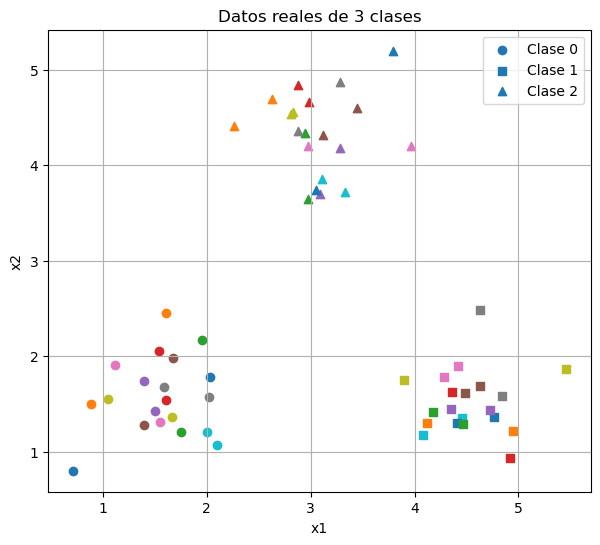

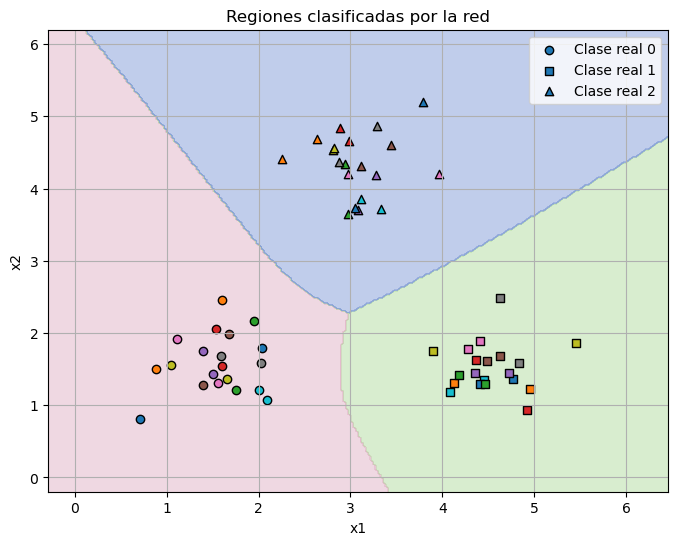

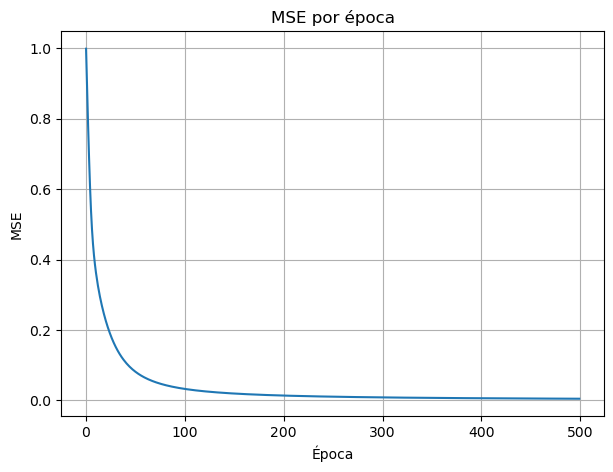

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

#Datos
np.random.seed(10)

# Clase 0
X0 = np.random.randn(20, 2) * 0.4 + np.array([1.5, 1.5])

# Clase 1
X1 = np.random.randn(20, 2) * 0.4 + np.array([4.5, 1.5])

# Clase 2
X2 = np.random.randn(20, 2) * 0.4 + np.array([3.0, 4.5])

# Unimos todos los datos
X = np.vstack((X0, X1, X2))

# Etiquetas reales
y_labels = np.array([0]*20 + [1]*20 + [2]*20)

T = np.zeros((len(y_labels), 3))

for i, c in enumerate(y_labels):
    T[i, c] = 1

#Funciones de activación
def tansig(n):
    return np.tanh(n)

def dtansig(a):
    return 1.0 - a**2

def logsig(n):
    return 1.0 / (1.0 + np.exp(-n))

def dlogsig(a):
    return a * (1.0 - a)

# neuronas de cada capa
n_input = 2
n_hidden = 6
n_output = 3

np.random.seed(7)

# Inicialización aleatoria de pesos y bias
W1 = np.random.randn(n_hidden, n_input) * 0.5
b1 = np.random.randn(n_hidden, 1) * 0.5

W2 = np.random.randn(n_output, n_hidden) * 0.5
b2 = np.random.randn(n_output, 1) * 0.5

#parámetros de entrenamiento
alpha = 0.01
epochs = 500

mse_list = []

# Número de patrones
Q = len(X)

for epoch in range(epochs):
    sum_error = 0.0

    for q in range(Q):
        # a^0 = p_q
        a0 = X[q].reshape(-1, 1)     # (2,1)

        # t_q
        tq = T[q].reshape(-1, 1)     # (3,1)

        # forward
        # n^1 = W^1 a^0 + b^1
        # a^1 = f^1(n^1)
        # n^2 = W^2 a^1 + b^2
        # a^2 = f^2(n^2)
        n1 = W1 @ a0 + b1
        a1 = tansig(n1)

        n2 = W2 @ a1 + b2
        a2 = logsig(n2)

        # ERROR
        # e_q = t_q - a_q^M
        e = tq - a2

        # Error cuadrático
        sum_error += (e.T @ e).item()

        # backpropagation
        # s^2 = -2 * F^2(n^2) * e
        # s^1 = F^1(n^1) * (W^2)^T * s^2
        s2 = -2 * dlogsig(a2) * e
        s1 = dtansig(a1) * (W2.T @ s2)

        # actualización
        # W^m = W^m - alpha * s^m * (a^(m-1))^T
        # b^m = b^m - alpha * s^m
        W2 = W2 - alpha * (s2 @ a1.T)
        b2 = b2 - alpha * s2

        W1 = W1 - alpha * (s1 @ a0.T)
        b1 = b1 - alpha * s1

    mse = sum_error / Q
    mse_list.append(mse)


def forward_point(x):
    
    a0 = np.array(x, dtype=float).reshape(-1, 1)

    n1 = W1 @ a0 + b1
    a1 = tansig(n1)

    n2 = W2 @ a1 + b2
    a2 = logsig(n2)

    return a2

#PREDICCIÓN SOBRE LOS DATOS DE ENTRENAMIENTO
Y_pred = []
class_pred = []

for q in range(Q):
    a2 = forward_point(X[q])

    Y_pred.append(a2.flatten())
    class_pred.append(np.argmax(a2))

Y_pred = np.array(Y_pred)
class_pred = np.array(class_pred)

#MÉTRICAS
num_classes = 3

#Matriz de confusión
conf_matrix = np.zeros((num_classes, num_classes), dtype=int)

for real, pred in zip(y_labels, class_pred):
    conf_matrix[real, pred] += 1

# Accuracy
accuracy = np.trace(conf_matrix) / np.sum(conf_matrix)

# Precision y recall por clase
precision = []
recall = []

for k in range(num_classes):
    TP = conf_matrix[k, k]
    FP = np.sum(conf_matrix[:, k]) - TP
    FN = np.sum(conf_matrix[k, :]) - TP

    prec_k = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    rec_k = TP / (TP + FN) if (TP + FN) > 0 else 0.0

    precision.append(prec_k)
    recall.append(rec_k)

#Resultados

print("\nMSE final =", mse_list[-1])

print("W1 =\n", W1)
print("b1 =\n", b1)
print("W2 =\n", W2)
print("b2 =\n", b2)

print("\nAccuracy =", accuracy)

print("\nConfusion Matrix:")
print(conf_matrix)

print("\nPrecision por clase:")
for k in range(num_classes):
    print(f"Clase {k}: {precision[k]:.4f}")

print("\nRecall por clase:")
for k in range(num_classes):
    print(f"Clase {k}: {recall[k]:.4f}")

print("\nClase real vs clase predicha:")
for real, pred in zip(y_labels, class_pred):
    print(f"real = {real}, pred = {pred}")

# Gráfica de los datos reales
plt.figure(figsize=(7, 6))

for i in range(Q):
    if y_labels[i] == 0:
        plt.scatter(X[i, 0], X[i, 1], marker='o', label='Clase 0' if i == 0 else "")
    elif y_labels[i] == 1:
        plt.scatter(X[i, 0], X[i, 1], marker='s', label='Clase 1' if i == 20 else "")
    else:
        plt.scatter(X[i, 0], X[i, 1], marker='^', label='Clase 2' if i == 40 else "")

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Datos reales de 3 clases")
plt.grid(True)
plt.legend()
plt.show()

# Regiones de decisión de la red
# Definimos límites del plano
x1_min, x1_max = X[:, 0].min() - 1.0, X[:, 0].max() + 1.0
x2_min, x2_max = X[:, 1].min() - 1.0, X[:, 1].max() + 1.0

#Creamos una malla
xx1, xx2 = np.meshgrid(
    np.linspace(x1_min, x1_max, 250),
    np.linspace(x2_min, x2_max, 250)
)


Z = np.zeros(xx1.shape, dtype=int)

for i in range(xx1.shape[0]):
    for j in range(xx1.shape[1]):
        punto = np.array([xx1[i, j], xx2[i, j]])
        a2 = forward_point(punto)
        Z[i, j] = np.argmax(a2)

# mapa de colores para fondo
cmap_fondo = ListedColormap(["#E1B3C6", "#B3DDA0", "#839DD9"])

plt.figure(figsize=(8, 6))

#Regiones
plt.contourf(xx1, xx2, Z, alpha=0.5, cmap=cmap_fondo)


for i in range(Q):
    if y_labels[i] == 0:
        plt.scatter(X[i, 0], X[i, 1], marker='o', edgecolors='black', label='Clase real 0' if i == 0 else "")
    elif y_labels[i] == 1:
        plt.scatter(X[i, 0], X[i, 1], marker='s', edgecolors='black', label='Clase real 1' if i == 20 else "")
    else:
        plt.scatter(X[i, 0], X[i, 1], marker='^', edgecolors='black', label='Clase real 2' if i == 40 else "")

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Regiones clasificadas por la red")
plt.grid(True)
plt.legend()
plt.show()

#Grafica de MSE por época
plt.figure(figsize=(7, 5))
plt.plot(mse_list)
plt.xlabel("Época")
plt.ylabel("MSE")
plt.title("MSE por época")
plt.grid(True)
plt.show()

#### Multilayer perceptron : 5 clases


MSE final = 0.05766754172396136
W1 =
 [[ 1.10264713  0.12348884]
 [ 0.85281414  0.10999824]
 [-2.91374776  1.34611018]
 [-0.14438219 -1.03398835]
 [ 0.72033718  0.54320823]
 [ 0.31780688 -1.28491679]
 [ 1.91958837 -0.66036666]
 [-0.67700212 -0.72976617]]
b1 =
 [[ 0.40679351]
 [-2.39394683]
 [ 0.53906801]
 [-0.87077802]
 [ 0.98345812]
 [ 2.67424715]
 [-4.18938435]
 [ 2.79006251]]
W2 =
 [[-0.66411665 -2.22079683 -1.16372138 -0.49993584 -0.1326415   1.18413176
  -0.98534465  3.15993359]
 [-1.53111759  0.65629891 -0.89779937  0.43612595 -1.35858805  3.37003063
   2.29518251 -0.86050233]
 [-0.71756677  1.15965939 -2.76864643  1.15491523 -2.38757817 -1.95809622
  -2.97889358 -0.68398051]
 [-0.27053809 -0.71970356  3.20641258  0.476718   -0.30705937 -0.90014715
  -0.90908579 -0.97389641]
 [-1.29132245  1.83824718 -0.42402764  1.23671423 -0.83721664 -3.28048321
   2.57364429  0.75404825]]
b2 =
 [[-0.8089498 ]
 [-1.21936907]
 [-2.16937224]
 [-0.90980339]
 [-0.81711261]]

Accuracy = 0.97

Confu

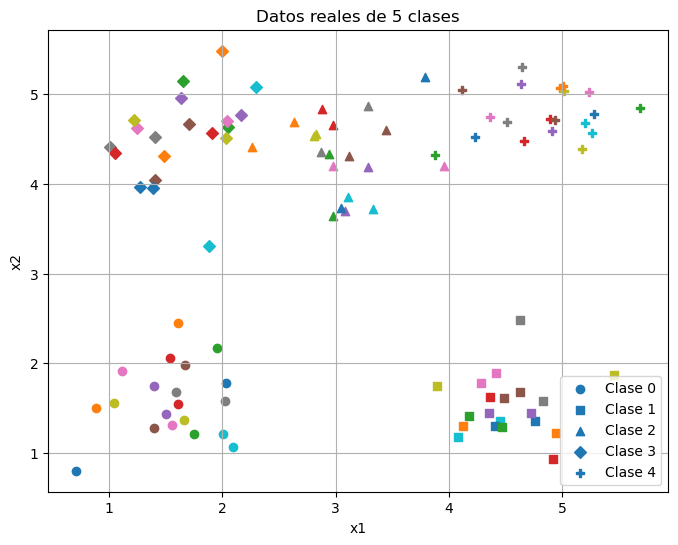

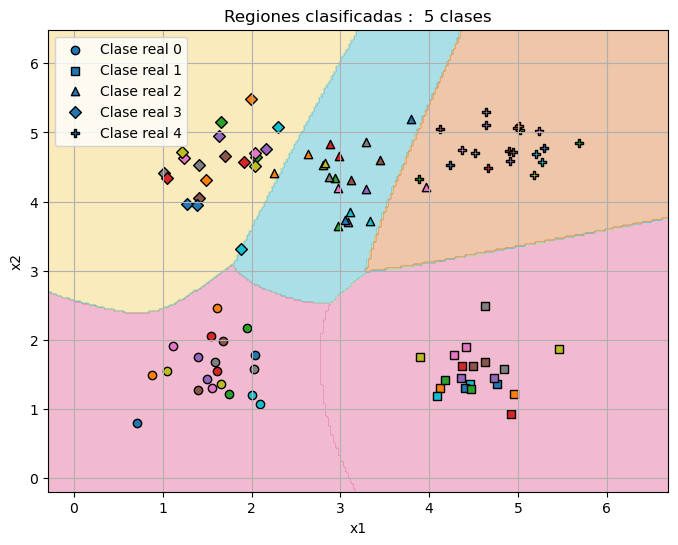

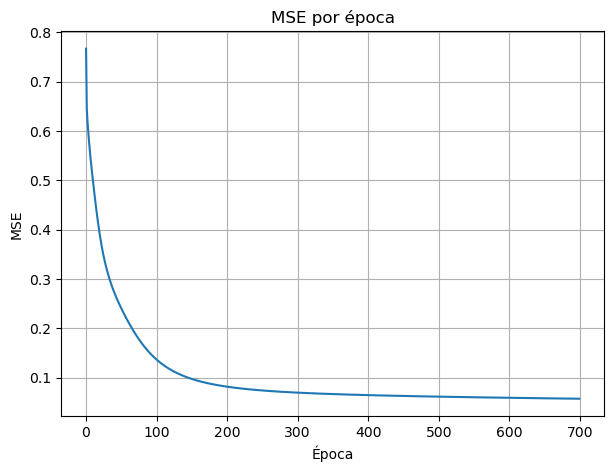

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

#Datos
np.random.seed(10)

# Clase 0
X0 = np.random.randn(20, 2) * 0.4 + np.array([1.5, 1.5])

# Clase 1
X1 = np.random.randn(20, 2) * 0.4 + np.array([4.5, 1.5])

# Clase 2
X2 = np.random.randn(20, 2) * 0.4 + np.array([3.0, 4.5])

# Clase 3
X3 = np.random.randn(20, 2) * 0.4 + np.array([1.5, 4.5])

# Clase 4
X4 = np.random.randn(20, 2) * 0.4 + np.array([4.8, 4.8])

#se unen los datos
X = np.vstack((X0, X1, X2, X3, X4))

# Etiquetas reales
y_labels = np.array([0]*20 + [1]*20 + [2]*20 + [3]*20 + [4]*20)

# Matriz de targets
T = np.zeros((len(y_labels), 5))

for i, c in enumerate(y_labels):
    T[i, c] = 1

#funciones de activación
def tansig(n):
    return np.tanh(n)

def dtansig(a):
    return 1.0 - a**2

def logsig(n):
    return 1.0 / (1.0 + np.exp(-n))

def dlogsig(a):
    return a * (1.0 - a)

#neuronas de cada capa
n_input = 2
n_hidden = 8
n_output = 5

np.random.seed(7)

# Inicialización aleatoria de pesos y bias
W1 = np.random.randn(n_hidden, n_input) * 0.5
b1 = np.random.randn(n_hidden, 1) * 0.5

W2 = np.random.randn(n_output, n_hidden) * 0.5
b2 = np.random.randn(n_output, 1) * 0.5

#parámetros de entrenamiento
alpha = 0.01
epochs = 700

mse_list = []

#número de patrones
Q = len(X)

#entrenamiento
for epoch in range(epochs):
    sum_error = 0.0

    for q in range(Q):
        # a^0 = p_q
        a0 = X[q].reshape(-1, 1) 

        # t_q
        tq = T[q].reshape(-1, 1)  

        # forward
        # n^1 = W^1 a^0 + b^1
        # a^1 = f^1(n^1)
        # n^2 = W^2 a^1 + b^2
        # a^2 = f^2(n^2)
        n1 = W1 @ a0 + b1
        a1 = tansig(n1)

        n2 = W2 @ a1 + b2
        a2 = logsig(n2)

        # ERROR
        # e_q = t_q - a_q^M
        e = tq - a2

        # Error cuadrático
        sum_error += (e.T @ e).item()

        # backpropagation
        # s^2 = -2 * F^2(n^2) * e
        # s^1 = F^1(n^1) * (W^2)^T * s^2
        s2 = -2 * dlogsig(a2) * e
        s1 = dtansig(a1) * (W2.T @ s2)

        # actualización
        # W^m = W^m - alpha * s^m * (a^(m-1))^T
        # b^m = b^m - alpha * s^m
        W2 = W2 - alpha * (s2 @ a1.T)
        b2 = b2 - alpha * s2

        W1 = W1 - alpha * (s1 @ a0.T)
        b1 = b1 - alpha * s1

    mse = sum_error / Q
    mse_list.append(mse)

#funcion forward para un punto
def forward_point(x):
    a0 = np.array(x, dtype=float).reshape(-1, 1)

    n1 = W1 @ a0 + b1
    a1 = tansig(n1)

    n2 = W2 @ a1 + b2
    a2 = logsig(n2)

    return a2

#predicción para datos de entrenamiento
Y_pred = []
class_pred = []

for q in range(Q):
    a2 = forward_point(X[q])

    Y_pred.append(a2.flatten())
    class_pred.append(np.argmax(a2))

Y_pred = np.array(Y_pred)
class_pred = np.array(class_pred)

#métricas
num_classes = 5

# Matriz de confusión
conf_matrix = np.zeros((num_classes, num_classes), dtype=int)

for real, pred in zip(y_labels, class_pred):
    conf_matrix[real, pred] += 1

# Accuracy
accuracy = np.trace(conf_matrix) / np.sum(conf_matrix)

# Precision y recall por clase
precision = []
recall = []

for k in range(num_classes):
    TP = conf_matrix[k, k]
    FP = np.sum(conf_matrix[:, k]) - TP
    FN = np.sum(conf_matrix[k, :]) - TP

    prec_k = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    rec_k = TP / (TP + FN) if (TP + FN) > 0 else 0.0

    precision.append(prec_k)
    recall.append(rec_k)

# resultados
print("\nMSE final =", mse_list[-1])

print("W1 =\n", W1)
print("b1 =\n", b1)
print("W2 =\n", W2)
print("b2 =\n", b2)

print("\nAccuracy =", accuracy)

print("\nConfusion Matrix:")
print(conf_matrix)

print("\nPrecision por clase:")
for k in range(num_classes):
    print(f"Clase {k}: {precision[k]:.4f}")

print("\nRecall por clase:")
for k in range(num_classes):
    print(f"Clase {k}: {recall[k]:.4f}")

print("\nClase real vs clase predicha:")
for real, pred in zip(y_labels, class_pred):
    print(f"real = {real}, pred = {pred}")

# =========================================================
# GRÁFICA DE LOS DATOS REALES
# =========================================================
plt.figure(figsize=(8, 6))

for i in range(Q):
    if y_labels[i] == 0:
        plt.scatter(X[i, 0], X[i, 1], marker='o', label='Clase 0' if i == 0 else "")
    elif y_labels[i] == 1:
        plt.scatter(X[i, 0], X[i, 1], marker='s', label='Clase 1' if i == 20 else "")
    elif y_labels[i] == 2:
        plt.scatter(X[i, 0], X[i, 1], marker='^', label='Clase 2' if i == 40 else "")
    elif y_labels[i] == 3:
        plt.scatter(X[i, 0], X[i, 1], marker='D', label='Clase 3' if i == 60 else "")
    else:
        plt.scatter(X[i, 0], X[i, 1], marker='P', label='Clase 4' if i == 80 else "")

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Datos reales de 5 clases")
plt.grid(True)
plt.legend()
plt.show()

#regiones de decisión de la red
x1_min, x1_max = X[:, 0].min() - 1.0, X[:, 0].max() + 1.0
x2_min, x2_max = X[:, 1].min() - 1.0, X[:, 1].max() + 1.0

# Creamos malla
xx1, xx2 = np.meshgrid(
    np.linspace(x1_min, x1_max, 250),
    np.linspace(x2_min, x2_max, 250)
)

Z = np.zeros(xx1.shape, dtype=int)

for i in range(xx1.shape[0]):
    for j in range(xx1.shape[1]):
        punto = np.array([xx1[i, j], xx2[i, j]])
        a2 = forward_point(punto)
        Z[i, j] = np.argmax(a2)

# mapa de colores para fondo
cmap_fondo = ListedColormap(["#E476A4", "#B3DDA0", "#59C0D0", "#F7D97C", "#DE8E56"])

plt.figure(figsize=(8, 6))

#Regiones
plt.contourf(xx1, xx2, Z, alpha=0.5, cmap=cmap_fondo)

for i in range(Q):
    if y_labels[i] == 0:
        plt.scatter(X[i, 0], X[i, 1], marker='o', edgecolors='black', label='Clase real 0' if i == 0 else "")
    elif y_labels[i] == 1:
        plt.scatter(X[i, 0], X[i, 1], marker='s', edgecolors='black', label='Clase real 1' if i == 20 else "")
    elif y_labels[i] == 2:
        plt.scatter(X[i, 0], X[i, 1], marker='^', edgecolors='black', label='Clase real 2' if i == 40 else "")
    elif y_labels[i] == 3:
        plt.scatter(X[i, 0], X[i, 1], marker='D', edgecolors='black', label='Clase real 3' if i == 60 else "")
    else:
        plt.scatter(X[i, 0], X[i, 1], marker='P', edgecolors='black', label='Clase real 4' if i == 80 else "")

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Regiones clasificadas :  5 clases")
plt.grid(True)
plt.legend()
plt.show()

#grafica de MSE por época
plt.figure(figsize=(7, 5))
plt.plot(mse_list)
plt.xlabel("Época")
plt.ylabel("MSE")
plt.title("MSE por época")
plt.grid(True)
plt.show()
